# Linear Regression on the Advertising Dataset (Kaggle)

**Goal:** predict product `sales` from advertising spend on `TV`, `radio`, and `newspaper`.

**Dataset source (Kaggle):** [Advertising Dataset](https://www.kaggle.com/datasets/ashydv/advertising-dataset) — 200 rows, each representing a market where a product is sold, with the advertising budget (in thousands of dollars) spent on three media, and the resulting sales (in thousands of units).

This notebook follows the standard supervised-learning workflow, one step at a time:

1. Load the dataset
2. Explore the data
3. Clean the data
4. Split into training and testing sets
5. Train a Linear Regression model
6. Evaluate the model (MAE, MSE, R²)
7. Predict on new, unseen samples
8. Wrap-up / conclusions


## 0. Import libraries

We need:
- `pandas` / `numpy` for data handling
- `matplotlib` / `seaborn` for visualization
- `scikit-learn` for the train/test split, the Linear Regression model, and evaluation metrics


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Load the dataset

The dataset is downloaded directly as a CSV (originally published on Kaggle as *Advertising Dataset*).
Each row is a market; columns are the ad budget for each channel (in \$1000s) and resulting `sales`
(in 1000s of units).


In [2]:
df = pd.read_csv("Advertising.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (200, 5)


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 2. Explore the data

Before touching anything, let's understand what we're working with:
- data types of each column
- missing values
- duplicate rows
- summary statistics (min, max, mean, spread)
- relationships between each advertising channel and `sales`
- correlation between variables


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
# Missing values per column
df.isnull().sum()


Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [5]:
# Duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [6]:
# Summary statistics
df.describe()


,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


### Visualizing relationships

A scatter plot of each advertising channel against `sales` gives a quick sense of which channels
actually drive sales, and whether the relationship looks roughly linear (a requirement for linear
regression to work well).


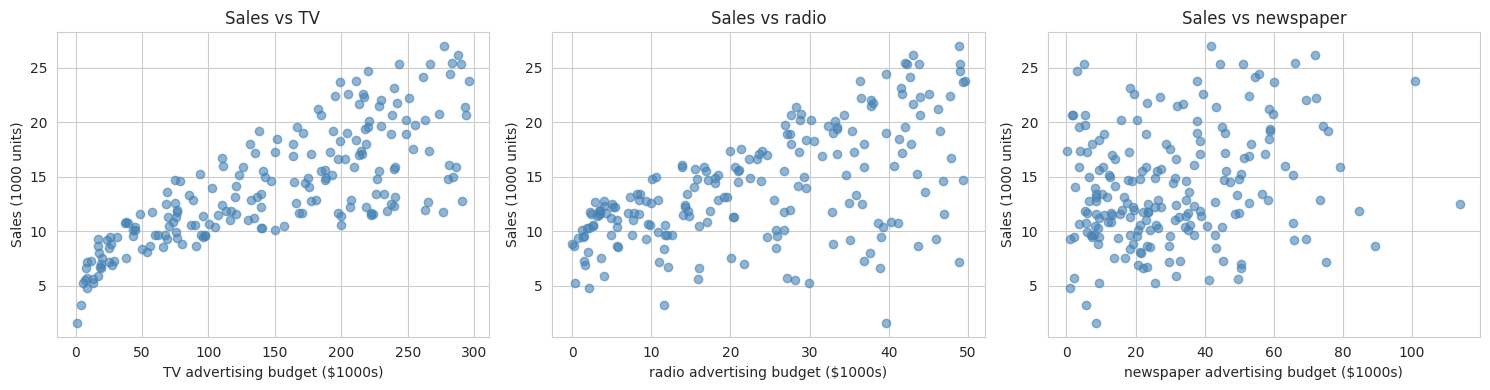

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["TV", "radio", "newspaper"]):
    ax.scatter(df[col], df["sales"], alpha=0.6, color="steelblue")
    ax.set_xlabel(f"{col} advertising budget ($1000s)")
    ax.set_ylabel("Sales (1000 units)")
    ax.set_title(f"Sales vs {col}")
plt.tight_layout()
plt.show()


**Observation:** `TV` shows the strongest, clearest linear relationship with `sales`. `radio` shows
a moderate positive trend. `newspaper` looks noisy and weakly related — we'll confirm this with a
correlation matrix next.


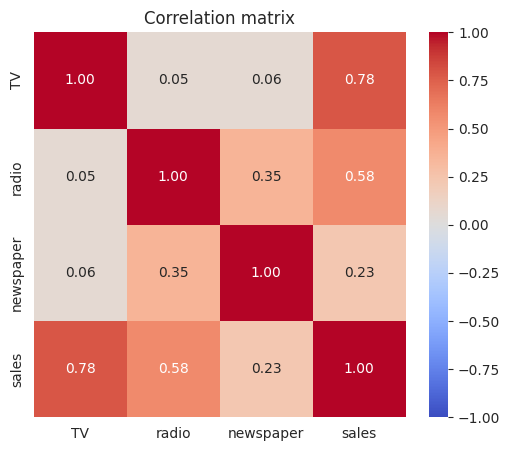

In [8]:
plt.figure(figsize=(6, 5))
corr = df[["TV", "radio", "newspaper", "sales"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.show()


**Observation:** `TV` (≈0.78) and `radio` (≈0.58) correlate strongly with `sales`. `newspaper`
(≈0.23) correlates weakly — it's likely to contribute little predictive power, but we'll keep it in
the model for now and let the regression coefficients confirm this quantitatively.

### Checking for outliers

A boxplot for each column helps spot extreme values that might distort the model.


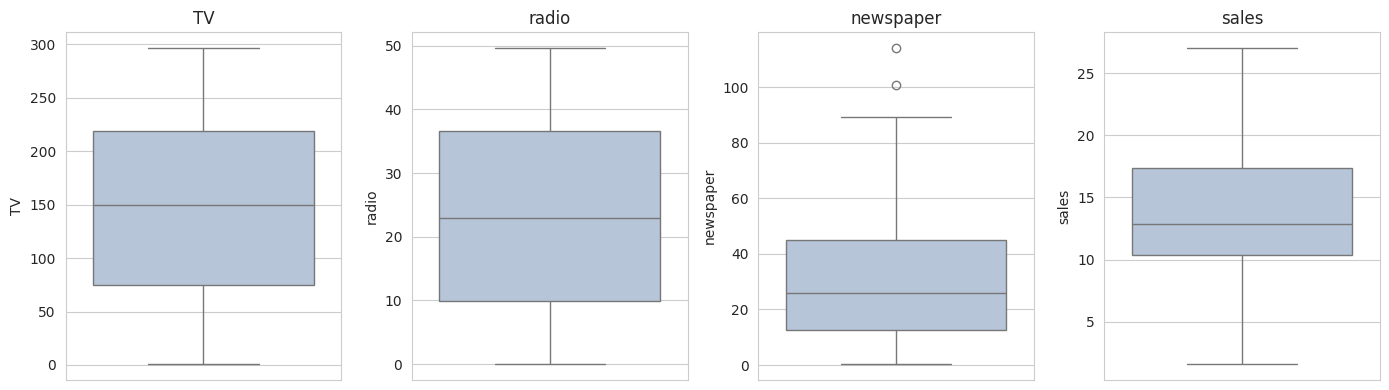

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, ["TV", "radio", "newspaper", "sales"]):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Observation:** `newspaper` has a few high-end outliers, but nothing extreme or clearly erroneous
(e.g. no negative budgets or impossible values) — so we'll keep all rows rather than discard data.


## 3. Clean the data

From the exploration above:
- There are **no missing values** and **no duplicate rows** — nothing to impute or drop there.
- The CSV includes a leftover index column (`Unnamed: 0`) from how the file was exported. It carries
  no information (it's just a row counter), so we drop it.
- Outliers in `newspaper` are mild and plausible (some markets really do spend a lot on newspaper
  ads), so we leave them in rather than removing real data points.


In [10]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Double check there's nothing left to clean
assert df.isnull().sum().sum() == 0, "There are still missing values!"
assert df.duplicated().sum() == 0, "There are still duplicate rows!"

df.head()


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 4. Split into training and testing sets

We hold out 20% of the data as a **test set** the model never sees during training. This lets us
measure how well the model generalizes to new, unseen markets — rather than just measuring how well
it memorized the training data.

- `X` = features (advertising budgets)
- `y` = target (`sales`)


In [11]:
feature_cols = ["TV", "radio", "newspaper"]
X = df[feature_cols]
y = df["sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 160
Testing samples:  40


## 5. Train a Linear Regression model

We fit an ordinary least squares Linear Regression model on the training data. The model learns a
coefficient for each feature plus an intercept:

$$\text{sales} = \beta_0 + \beta_1 \cdot TV + \beta_2 \cdot radio + \beta_3 \cdot newspaper$$


In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_
})
print(coef_table.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")


  feature  coefficient
       TV     0.044730
    radio     0.189195
newspaper     0.002761

Intercept: 2.9791


**Interpreting the coefficients:** holding the other channels constant, each extra \$1000 spent on
`TV` is associated with an increase in sales of about `coef_TV` thousand units, and similarly for
`radio`. If the `newspaper` coefficient is small (or even slightly negative), that confirms what we
saw in the correlation matrix — newspaper spend has little independent effect on sales once TV and
radio are accounted for.


## 6. Evaluate the model

We measure performance on **both** the training and test sets using three standard regression
metrics:

- **MAE (Mean Absolute Error):** average absolute difference between predicted and actual sales — in
  the same units as `sales` (1000s of units). Easy to interpret, robust to outliers.
- **MSE (Mean Squared Error):** average of the squared errors. Penalizes large errors more heavily
  than MAE.
- **R² (coefficient of determination):** proportion of variance in `sales` explained by the model.
  1.0 = perfect fit, 0.0 = no better than predicting the mean.

Comparing train vs. test performance also tells us whether the model is overfitting (much better on
train than test) or underfitting (poor on both).


In [13]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} set:")
    print(f"  MAE  = {mae:.3f}")
    print(f"  MSE  = {mse:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print(f"  R^2  = {r2:.4f}\n")
    return mae, mse, r2

train_metrics = evaluate(y_train, y_pred_train, "Training")
test_metrics  = evaluate(y_test, y_pred_test, "Test")


Training set:
  MAE  = 1.198
  MSE  = 2.705
  RMSE = 1.645
  R^2  = 0.8957

Test set:
  MAE  = 1.461
  MSE  = 3.174
  RMSE = 1.782
  R^2  = 0.8994



### Visualizing predictions

Two useful diagnostic plots:
1. **Actual vs. predicted** — points should cluster tightly around the diagonal line for a good fit.
2. **Residuals plot** — the errors (actual − predicted) should scatter randomly around zero, with no
   obvious pattern. A visible curve or funnel shape would suggest the linear model is missing
   something (e.g. a non-linear relationship).


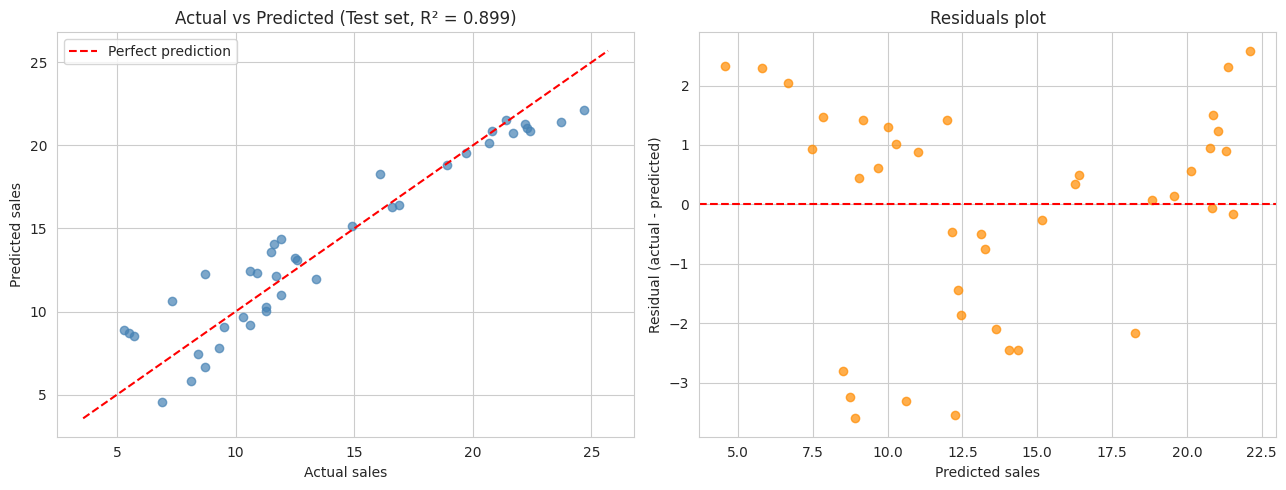

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.7, color="steelblue")
lims = [min(y_test.min(), y_pred_test.min()) - 1, max(y_test.max(), y_pred_test.max()) + 1]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual sales")
axes[0].set_ylabel("Predicted sales")
axes[0].set_title(f"Actual vs Predicted (Test set, R² = {test_metrics[2]:.3f})")
axes[0].legend()

# Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.7, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted sales")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals plot")

plt.tight_layout()
plt.show()


**Observation:** points cluster closely around the diagonal in the left plot, and the residuals on
the right scatter randomly around zero with no obvious pattern — both are good signs that a linear
model is a reasonable fit for this data.


## 7. Predict on new samples

Finally, let's use the trained model to predict sales for a few **hypothetical new markets** with
advertising budgets it has never seen before.


In [15]:
new_markets = pd.DataFrame([
    {"TV": 200.0, "radio": 40.0, "newspaper": 30.0},   # heavy TV + radio spend
    {"TV": 20.0,  "radio": 5.0,  "newspaper": 10.0},   # small budget across the board
    {"TV": 100.0, "radio": 25.0, "newspaper": 50.0},   # mid-range, newspaper-heavy
], columns=feature_cols)

predicted_sales = model.predict(new_markets)

result = new_markets.copy()
result["predicted_sales"] = np.round(predicted_sales, 2)
result


,TV,radio,newspaper,predicted_sales
0,200.0,40.0,30.0,19.58
1,20.0,5.0,10.0,4.85
2,100.0,25.0,50.0,12.32


These predictions are in the same units as the training target — thousands of units sold — so, for
example, the first market (heavy TV + radio spend) is predicted to sell the most units, consistent
with TV and radio being the strongest drivers of sales we identified during exploration.


## 8. Conclusion

- The dataset ([Kaggle: Advertising Dataset](https://www.kaggle.com/datasets/ashydv/advertising-dataset))
  needed minimal cleaning — just dropping a stray index column.
- A simple Linear Regression model using `TV`, `radio`, and `newspaper` spend explains a large share
  of the variance in `sales` (see the R² above) with a test MAE of just a few thousand units.
- `TV` and `radio` spend are the strongest, most reliable drivers of sales; `newspaper` spend
  contributes comparatively little once the other two are accounted for.
- The model generalizes well — training and test metrics are close, indicating no significant
  overfitting.

**Possible next steps:** try removing `newspaper` and compare performance, engineer interaction
terms (e.g. `TV * radio`), or try polynomial/regularized regression to see if a more flexible model
improves the fit further.
